In [1]:
import utils
import numpy as np
from ax.service.ax_client import AxClient, ObjectiveProperties
from ax.modelbridge.factory import Generators
from ax.modelbridge.generation_strategy import GenerationStep, GenerationStrategy
from botorch.acquisition import ExpectedImprovement

from ax.service.utils.best_point import get_trace

import matplotlib.pyplot as plt

import time

/var/folders/9p/f66yhymx35939zzlg51g0rrc0000gn/T/ipykernel_27493/3322308737.py:5: DeprecationWarning: Please import from 'ax.generation_strategy.generation_strategy' instead of 'ax.modelbridge.generation_strategy'. The latter is deprecated and will be removed in a future release.
  from ax.modelbridge.generation_strategy import GenerationStep, GenerationStrategy


In [2]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
obj1_name = 'f1'
obj2_name = 'f2'
obj3_name = 'f3'

models_list = [Generators.SAASBO, Generators.BO_MIXED, Generators.BOTORCH_MODULAR]

total_trials = 120

sobol_count = 100
trial_num = total_trials - sobol_count

trial_parameters = [
    {"name": "x1", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x2", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x3", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x4", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x5", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x6", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x7", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x8", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x9", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x10", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x11", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x12", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x13", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x14", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"}
]

trial_objectives = {
    obj1_name: ObjectiveProperties(minimize=True),
    obj2_name: ObjectiveProperties(minimize=True),
    obj3_name: ObjectiveProperties(minimize=True),
}

In [3]:
traces = []
for model in models_list:
    traces.append(np.zeros((len(seed_list), total_trials)))

times = []
for model in models_list:
    times.append(np.zeros((len(seed_list), total_trials)))

[WARNING 07-11 17:06:31] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-11 17:06:31] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, but should be specified on the objective for best performance.
[WARNING 07-11 17:06:33] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-11 17:06:33] ax.service.util

[299.08962589 299.08962589 372.83123731 372.83123731 372.83123731
 372.83123731 372.83123731 372.83123731 374.17033825 374.17033825
 374.17033825 374.17033825 374.17033825 393.7245732  393.7245732
 393.7245732  653.10517889 653.10517889 653.10517889 653.10517889
 653.10517889 653.10517889 653.10517889 653.10517889 653.10517889
 653.10517889 653.10517889 653.10517889 653.10517889 654.95363919
 654.95363919 654.95363919 655.25132323 655.25132323 655.25132323
 655.25132323 655.25132323 655.25132323 655.38391817 655.38391817
 655.38391817 655.38391817 655.38391817 655.38391817 655.38391817
 655.38391817 655.38391817 655.38391817 664.79720123 664.79720123
 664.79720123 664.79720123 665.18597507 665.18597507 665.18597507
 665.18597507 665.25664052 665.25664052 665.25664052 665.25664052
 665.25664052 665.25664052 665.25664052 665.25664052 665.25664052
 665.25664052 665.25664052 665.25664052 665.25664052 665.25664052
 665.25664052 665.25664052 665.25664052 665.25664052 708.11464254
 708.114642

[WARNING 07-11 18:29:26] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-11 18:29:26] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, but should be specified on the objective for best performance.


[298.026969   298.026969   371.15712046 371.15712046 371.15712046
 371.15712046 371.15712046 371.15712046 372.4962214  372.4962214
 372.4962214  372.4962214  372.4962214  392.05045635 392.05045635
 392.05045635 650.20267732 650.20267732 650.20267732 650.20267732
 650.20267732 650.20267732 650.20267732 650.20267732 650.20267732
 650.20267732 650.20267732 650.20267732 650.20267732 652.05113762
 652.05113762 652.05113762 652.34882166 652.34882166 652.34882166
 652.34882166 652.34882166 652.34882166 652.47971112 652.47971112
 652.47971112 652.47971112 652.47971112 652.47971112 652.47971112
 652.47971112 652.47971112 652.47971112 661.89299418 661.89299418
 661.89299418 661.89299418 662.28176802 662.28176802 662.28176802
 662.28176802 662.35243347 662.35243347 662.35243347 662.35243347
 662.35243347 662.35243347 662.35243347 662.35243347 662.35243347
 662.35243347 662.35243347 662.35243347 662.35243347 662.35243347
 662.35243347 662.35243347 662.35243347 662.35243347 704.95162153
 704.951621

/opt/anaconda3/envs/drug_surfactant/lib/python3.11/site-packages/botorch/acquisition/analytic.py:331: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/opt/anaconda3/envs/drug_surfactant/lib/python3.11/site-packages/botorch/acquisition/analytic.py:331: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/opt/anaconda3/envs/drug_surfactan

...

[184.6128893  269.17695329 269.17695329 269.17695329 269.17695329
 269.61451709 269.61451709 300.39980786 300.39980786 312.14490037
 312.14490037 312.14490037 312.14490037 312.14490037 380.58704392
 472.67193379 472.67193379 481.63821223 481.63821223 481.63821223
 481.63821223 481.63821223 481.63821223 481.90460449 481.90460449
 481.90460449 481.90460449 481.90460449 481.90460449 481.90460449
 481.90460449 548.45036948 548.45036948 578.47865943 578.47865943
 578.47865943 578.47865943 578.47865943 578.47865943 697.00352394
 697.00352394 697.00352394 697.00352394 697.00352394 697.00352394
 697.00352394 697.00352394 700.74674965 700.74674965 700.74674965
 700.74674965 700.74674965 700.74674965 700.74674965 700.74674965
 702.20774816 702.20774816 702.20774816 702.20774816 702.98002728
 702.98002728 702.98002728 702.98002728 747.65125096 747.65125096
 752.4336751  752.4336751  752.4336751  752.4336751  752.4336751
 752.4336751  752.9991254  754.64939753 757.71159612 757.71159612
 757.711596

[WARNING 07-12 07:26:39] ax.service.ax_client: Random seed set to 9. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-12 07:26:39] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, but should be specified on the objective for best performance.


[155.9467052  227.04822634 227.04822634 227.04822634 227.04822634
 227.48579014 227.48579014 258.27108091 258.27108091 270.01617342
 270.01617342 270.01617342 270.01617342 270.01617342 338.45831697
 422.39175907 422.39175907 430.09254083 430.09254083 430.09254083
 430.09254083 430.09254083 430.09254083 430.35893309 430.35893309
 430.35893309 430.35893309 430.35893309 430.35893309 430.35893309
 430.35893309 494.24208917 494.24208917 520.48926445 520.48926445
 520.48926445 520.48926445 520.48926445 520.48926445 622.33874713
 622.33874713 622.33874713 622.33874713 622.33874713 622.33874713
 622.33874713 622.33874713 626.08197284 626.08197284 626.08197284
 626.08197284 626.08197284 626.08197284 626.08197284 626.08197284
 627.53092615 627.53092615 627.53092615 627.53092615 628.30320527
 628.30320527 628.30320527 628.30320527 672.97442895 672.97442895
 677.05821264 677.05821264 677.05821264 677.05821264 677.05821264
 677.05821264 677.51884783 679.16911996 682.23131855 682.23131855
 682.23131

/opt/anaconda3/envs/drug_surfactant/lib/python3.11/site-packages/botorch/acquisition/analytic.py:331: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/opt/anaconda3/envs/drug_surfactant/lib/python3.11/site-packages/botorch/acquisition/analytic.py:331: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
/opt/anaconda3/envs/drug_surfactan

[ 203.28033735  296.61122285  296.61122285  296.61122285  296.61122285
  297.04878665  297.04878665  327.83407742  327.83407742  339.57916993
  339.57916993  339.57916993  339.57916993  339.57916993  408.02131348
  505.41443437  505.41443437  515.20480552  515.20480552  515.20480552
  515.20480552  515.20480552  515.20480552  515.47119779  515.47119779
  515.47119779  515.47119779  515.47119779  515.47119779  515.47119779
  515.47119779  583.7508564   583.7508564   616.24141203  616.24141203
  616.24141203  616.24141203  616.24141203  616.24141203  745.62530205
  745.62530205  745.62530205  745.62530205  745.62530205  745.62530205
  745.62530205  745.62530205  749.36852775  749.36852775  749.36852775
  749.36852775  749.36852775  749.36852775  749.36852775  749.36852775
  750.83737011  750.83737011  750.83737011  750.83737011  751.60964923
  751.60964923  751.60964923  751.60964923  796.28087291  796.28087291
  801.51825243  801.51825243  801.51825243  801.51825243  801.51825243
  801.

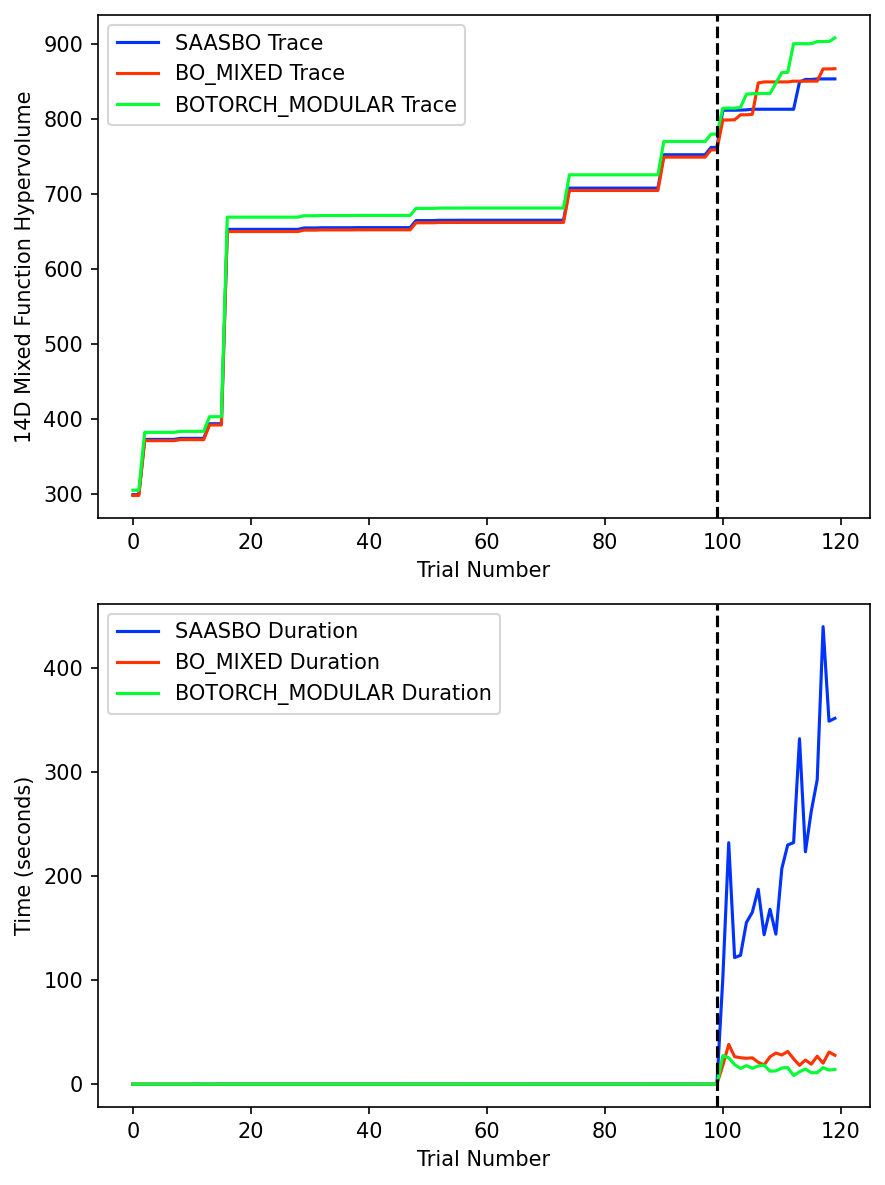

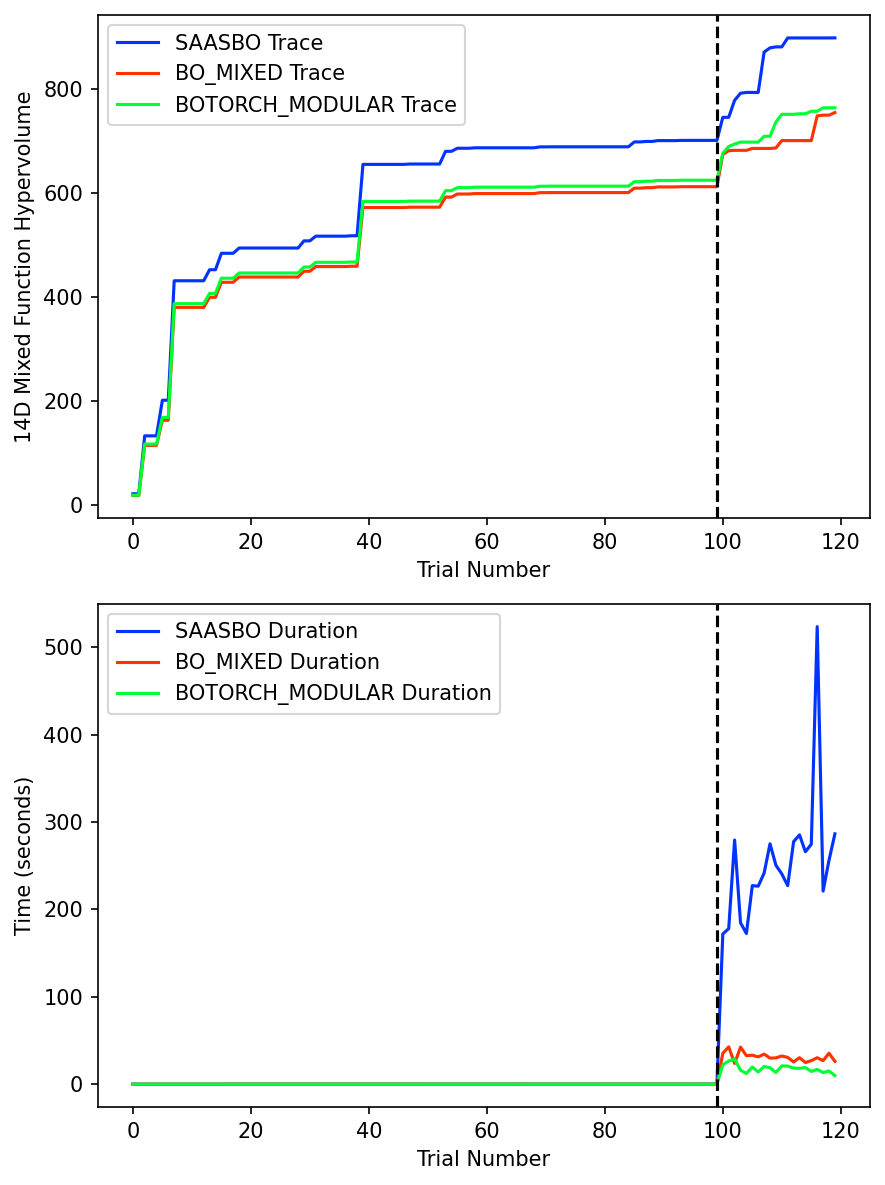

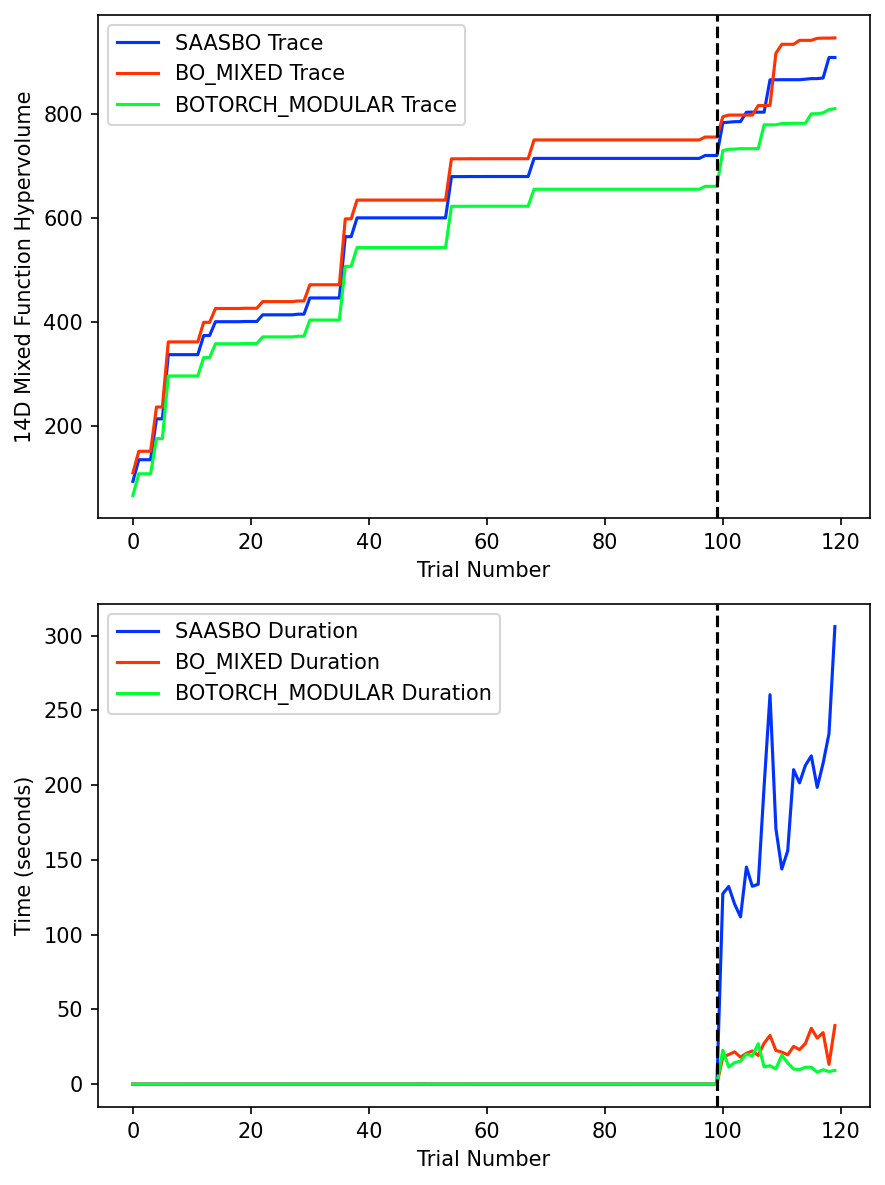

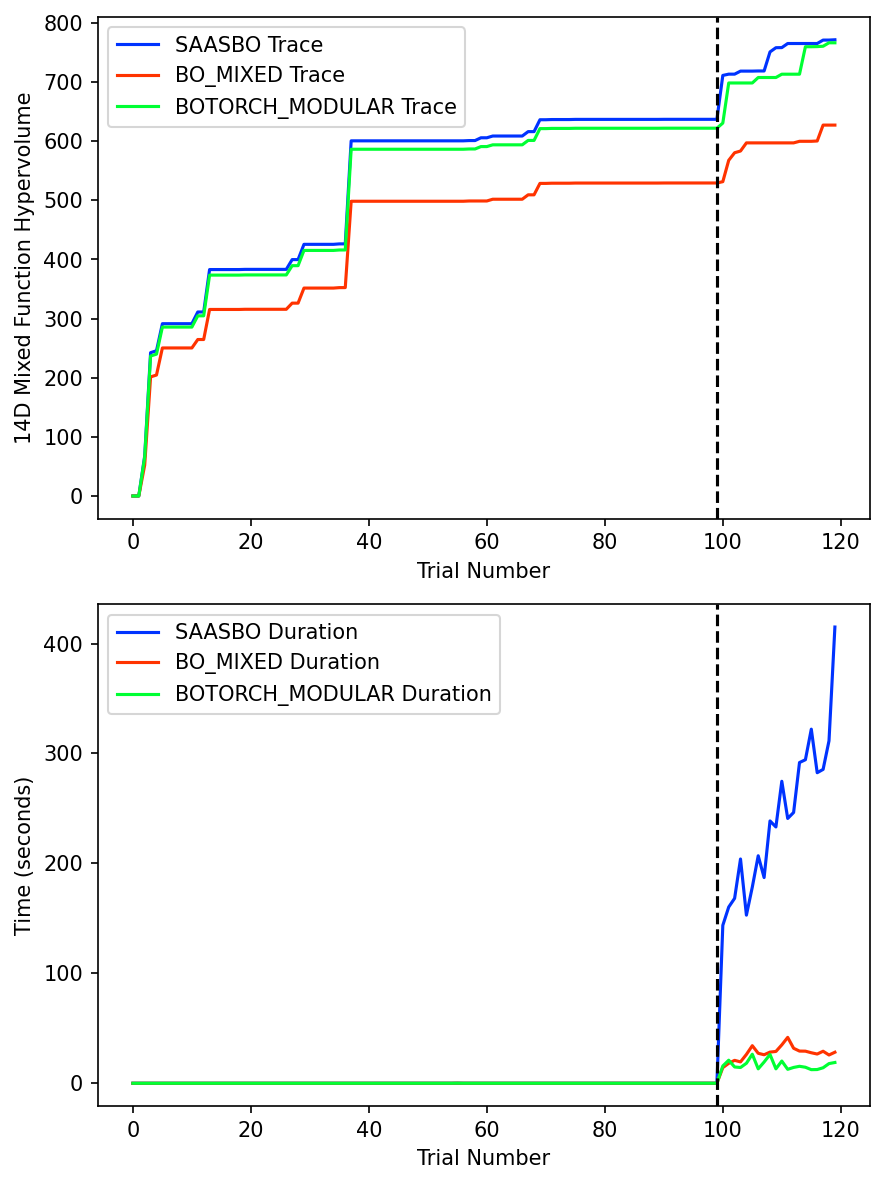

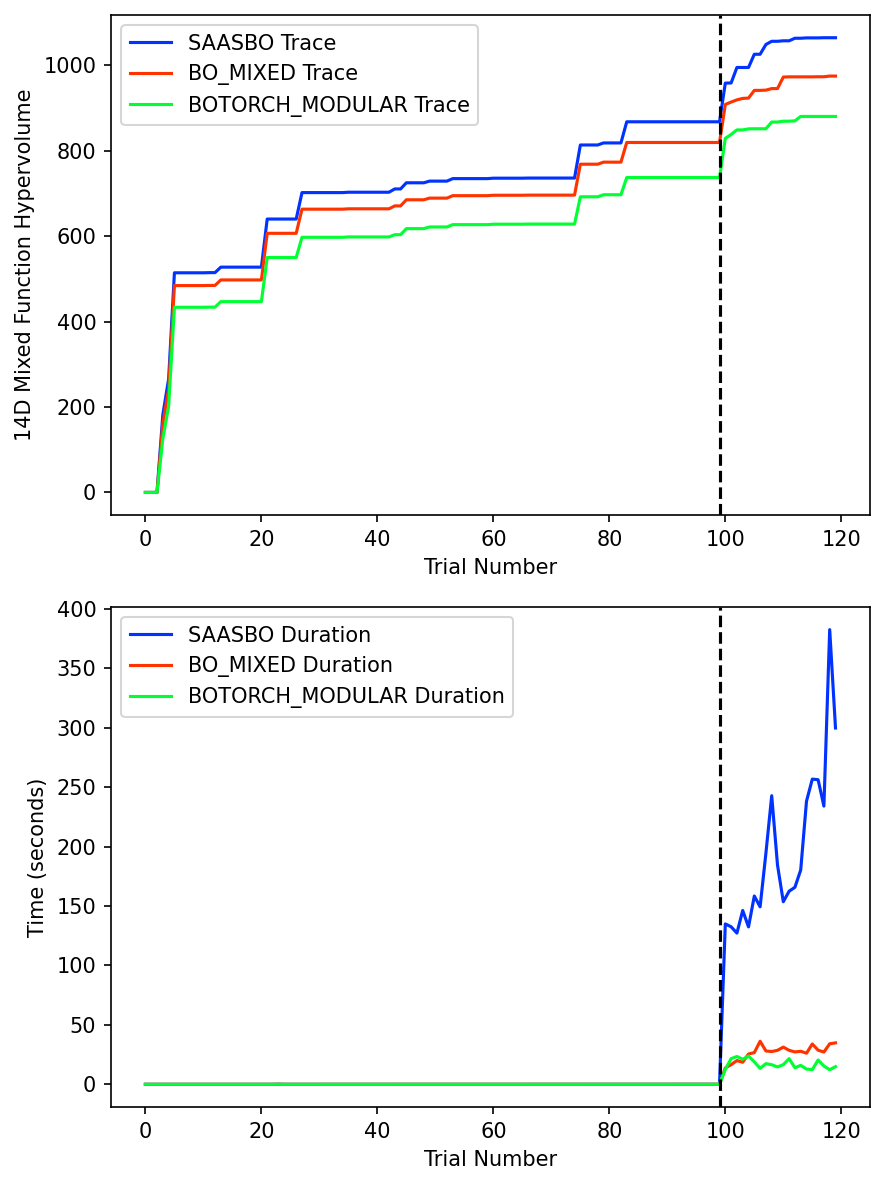

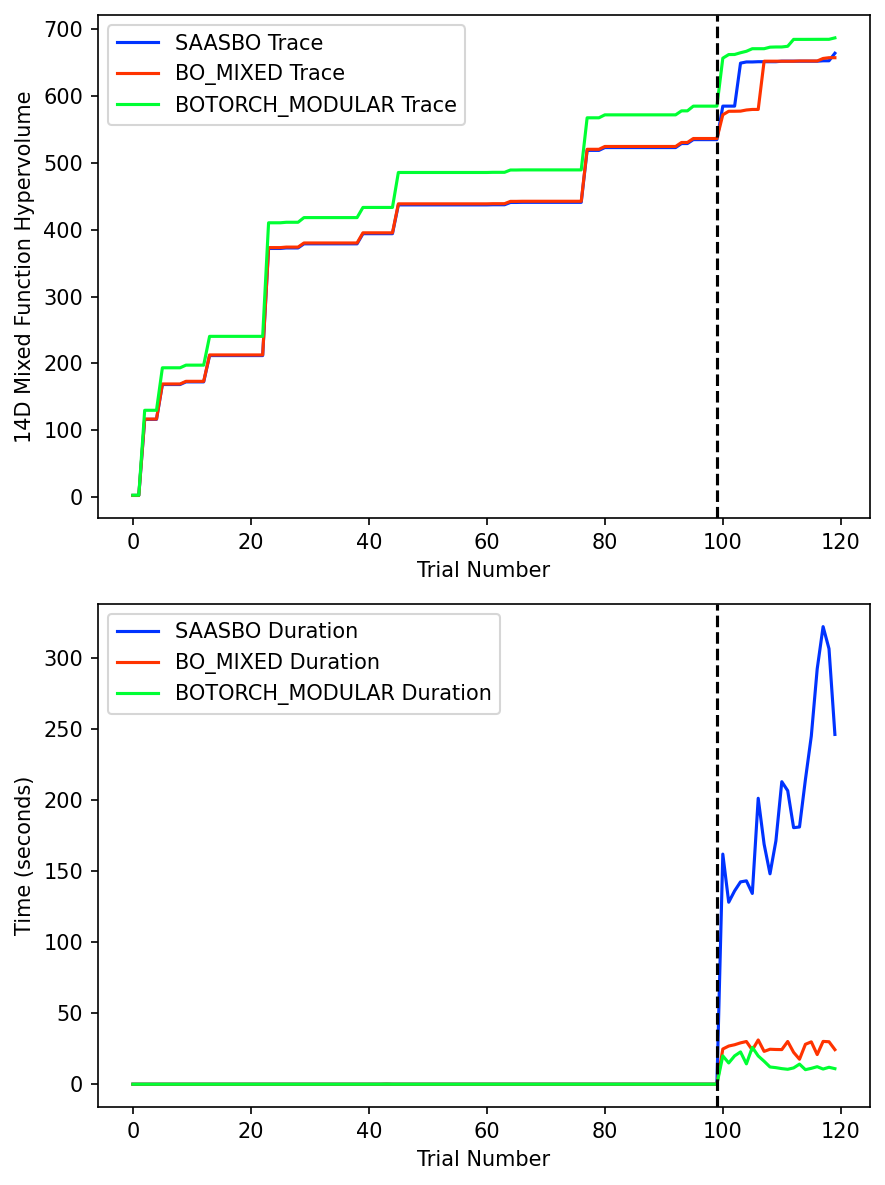

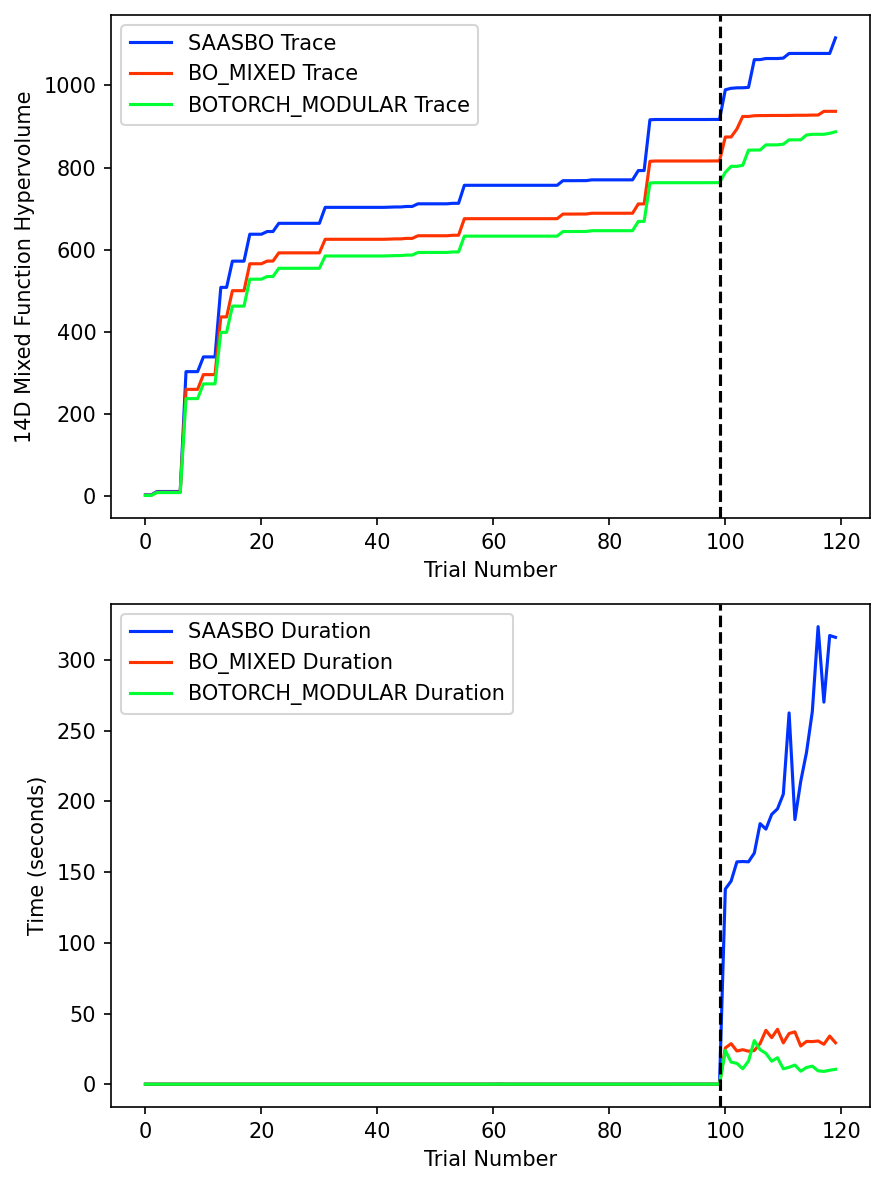

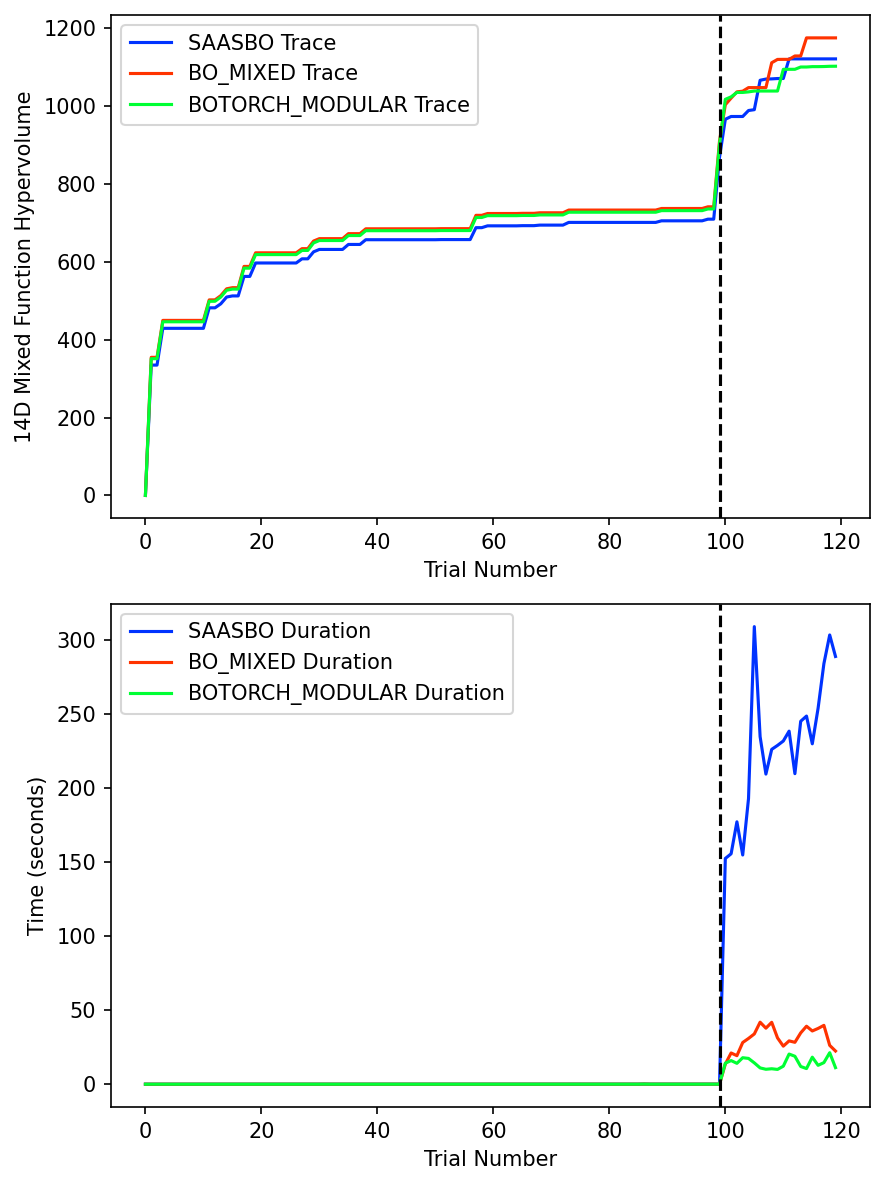

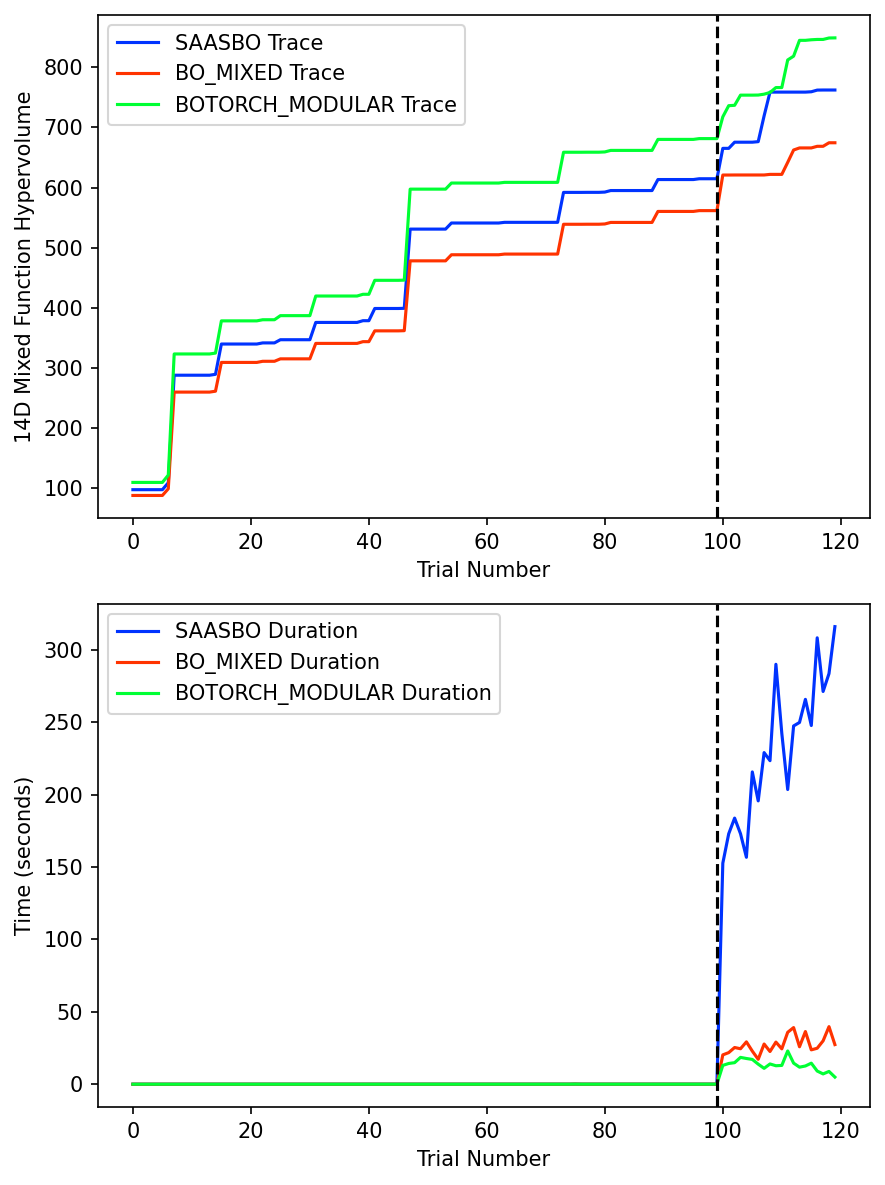

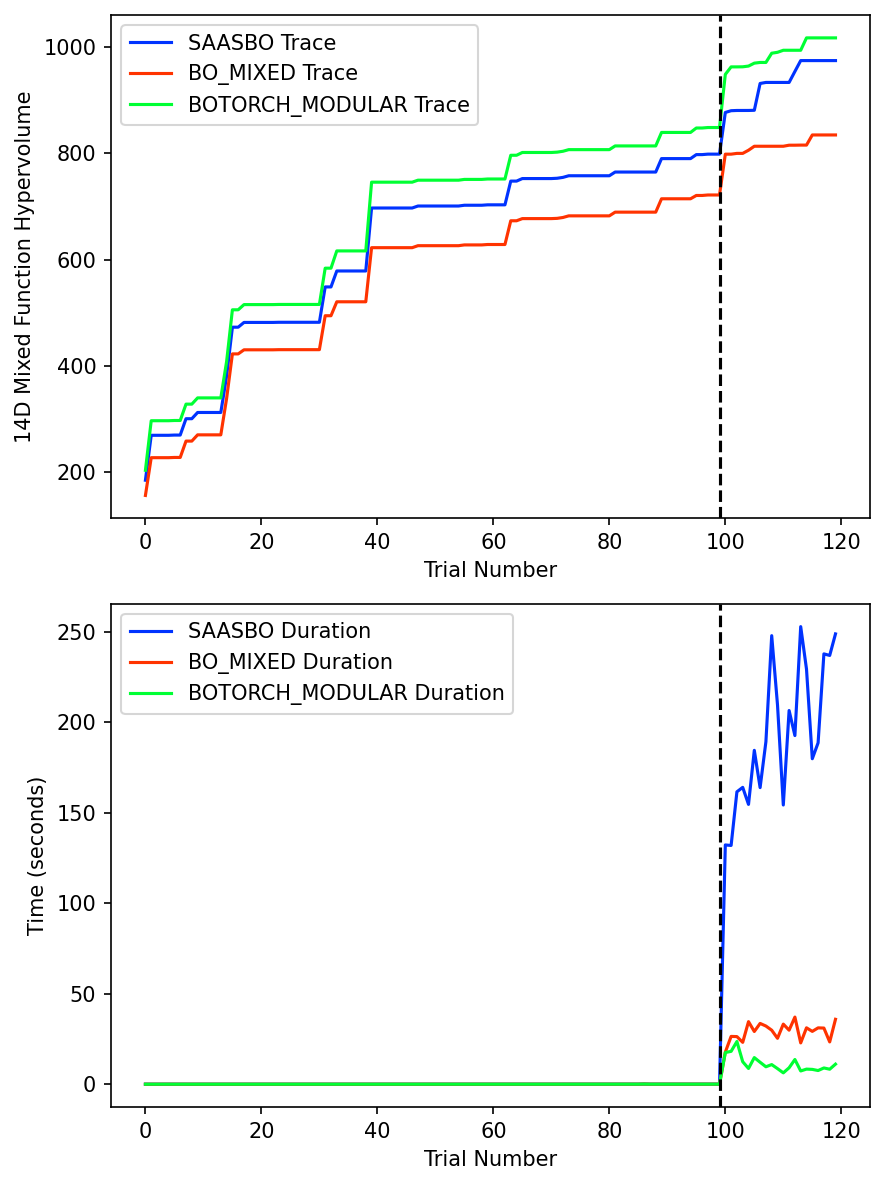

In [4]:
for j, seed in enumerate(seed_list):
    utils.set_seeds(seed)  # setting the random seed for reproducibility

    # generate same sobol trials for all models
    sobol_trials = []
    sobol_client = AxClient(
        generation_strategy=GenerationStrategy(
            steps=[
                GenerationStep(
                    model=Generators.SOBOL,
                    num_trials=sobol_count,
                    min_trials_observed=3,
                    max_parallelism=5,
                    model_kwargs={"seed": seed},
                    model_gen_kwargs={},
                ),
            ]
        ),
        verbose_logging=False,
        random_seed=seed)
    
    sobol_client.create_experiment(
        parameters=trial_parameters,
        objectives=trial_objectives,
    )

    for a in range(sobol_count):
        start_time = time.time()
        parameterization, trial_index = sobol_client.get_next_trial()
        time_taken = time.time() - start_time
        
        for mod_time in times:
            mod_time[j, a] = time_taken

        x = np.array([parameterization[f"x{i+1}"] for i in range(14)])

        results = utils.polynomial_14d(x)
        sobol_trials.append([results, parameterization])
        sobol_client.complete_trial(trial_index=trial_index, raw_data=results)

    for i, model in enumerate(models_list):
        gs = GenerationStrategy(
            steps=[
                #GenerationStep(
                #    model=Generators.SOBOL,
                #    num_trials=sobol_count,
                #    min_trials_observed=3,
                #    max_parallelism=5,
                #    model_kwargs={"seed": seed},
                #    model_gen_kwargs={},
                #),
                GenerationStep(
                    model=model,
                    num_trials=-1,
                    max_parallelism=3,
                    model_kwargs={"botorch_acqf_class": ExpectedImprovement} if model == Generators.BOTORCH_MODULAR else {},
                ),
            ]
        )

        ax_client = AxClient(generation_strategy=gs,
                                verbose_logging=False,
                                random_seed=seed)

        ax_client.create_experiment(
            parameters=trial_parameters,
            objectives=trial_objectives,
        )

        for a, (result, parameterization) in enumerate(sobol_trials):
            ax_client.attach_trial(parameters=parameterization)
            ax_client.complete_trial(trial_index=a, raw_data=result)
        traces[i][j, :sobol_count] = get_trace(ax_client._experiment)[:sobol_count]

        for a in range(trial_num):
            start_time = time.time()
            parameterization, trial_index = ax_client.get_next_trial()
            times[i][j, sobol_count + a] = time.time() - start_time

            x = np.array([parameterization[f"x{i+1}"] for i in range(14)])

            results = utils.mixed_14d(x)
            ax_client.complete_trial(trial_index=trial_index, raw_data=results)

        traces[i][j, :] = get_trace(ax_client._experiment)#[sobol_count:]
        print(traces[i][j, :], "for model:", i, "seed:", seed)
        print(times[i][j, :], "for model:", i, "seed:", seed)
    
    # plot for each seed
    objective = '14D Mixed Function Hypervolume'
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), dpi=150)

    for trace, duration, name in zip(traces, times, ["SAASBO", "BO_MIXED", "BOTORCH_MODULAR"]):

        color = '#0033FF' if name == "SAASBO" else '#FF3300'
        color = '#00FF33' if name == "BOTORCH_MODULAR" else color

        ax1.plot(trace[j], color=color, label=f"{name} Trace")
        print(seed, trace[j])

        ax2.plot(duration[j], color=color, label=f"{name} Duration")
        print(seed, duration[j])

    for ax in [ax1, ax2]:
        ax.axvline(sobol_count - 1, color='black', linestyle='--') # mark end of SOBOL trials
        ax.set_xlabel("Trial Number")
        ax.legend()

    ax1.set_ylabel(objective)

    ax2.set_ylabel("Time (seconds)")

    plt.tight_layout()
    #plt.show()
    plt.savefig("14_parameter_benches/mixed_multi_macmini/gen_strategy_bench_mixed14D_seed{}.png".format(seed), dpi=150)


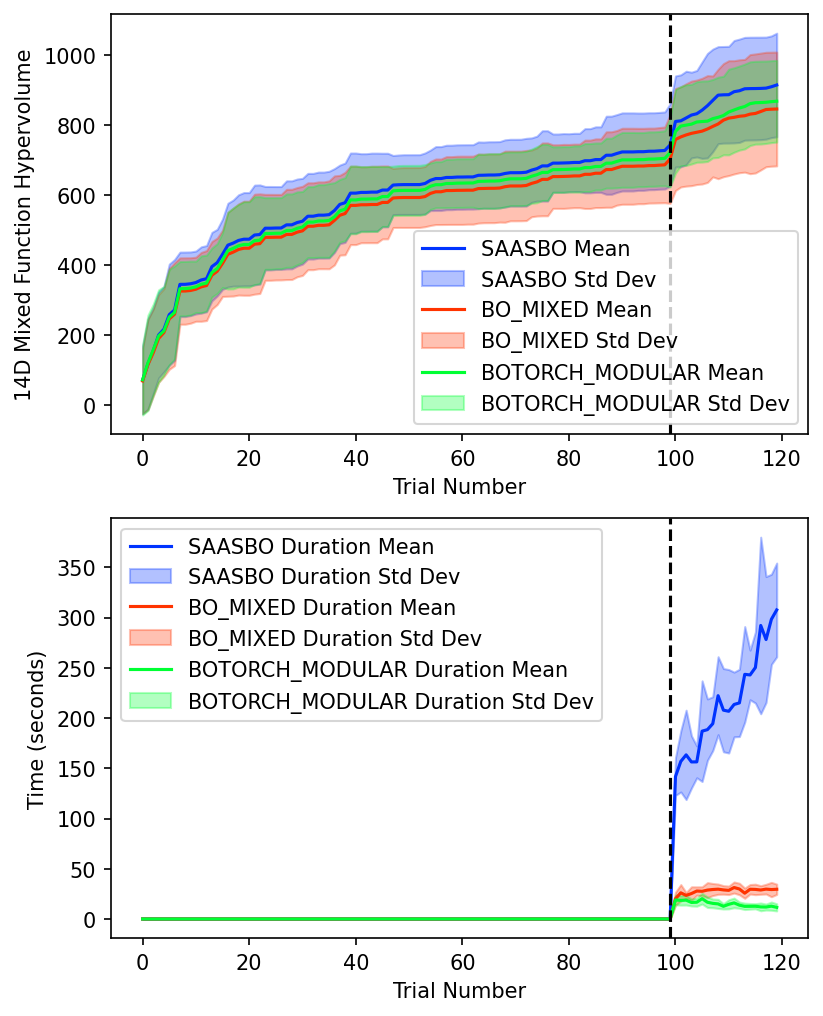

In [5]:

# plot everything together
objective = '14D Mixed Function Hypervolume'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), dpi=150)

for trace, duration, name in zip(traces, times, ["SAASBO", "BO_MIXED", "BOTORCH_MODULAR"]):

    trace_mean = np.mean(trace, axis=0)
    trace_std = np.std(trace, axis=0)

    duration_mean = np.mean(duration, axis=0)
    duration_std = np.std(duration, axis=0)

    color = '#0033FF' if name == "SAASBO" else '#FF3300'
    color = '#00FF33' if name == "BOTORCH_MODULAR" else color

    ax1.plot(trace_mean, color=color, label=f"{name} Mean")
    ax1.fill_between(
        range(len(trace_mean)), trace_mean - trace_std, trace_mean + trace_std,
        color=color, alpha=0.3, label=f"{name} Std Dev"
    )

    ax2.plot(duration_mean, color=color, label=f"{name} Duration Mean")
    ax2.fill_between(
        range(len(duration_mean)), duration_mean - duration_std, duration_mean + duration_std,
        color=color, alpha=0.3, label=f"{name} Duration Std Dev"
    )

for ax in [ax1, ax2]:
    ax.axvline(sobol_count - 1, color='black', linestyle='--') # mark end of SOBOL trials
    ax.set_xlabel("Trial Number")
    ax.legend()

ax1.set_ylabel(objective)

ax2.set_ylabel("Time (seconds)")
#plt.show()
plt.savefig("14_parameter_benches/mixed_multi_macmini/gen_strategy_bench_mixed14D_mean_and_std.png", dpi=150)